In [1]:
# -------------------------------------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, precision_recall_curve, roc_auc_score,
    classification_report, hamming_loss, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------------------
# 2. LOAD DATA (your Excel file from Google Forms)
# -------------------------------------------------------------
df = pd.read_excel("Austism Survey Datasett.xlsx", header=1)  # use row 2 as header

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (300, 84)


,Unnamed: 0,Child gender,Child‘s age,How professionals described your child's current level of support?,The age of child showing autistic traits?,How does your child usually communicate with you in daily life?,Your child's walking and mobility characteristics when going out?,How often do your child use Snoezelen room(Calm room)?,Snoezelen room is effective for my child.,The cost of using Snoezelen room is high for me.,...,I am willing to use a sensory smart stroller which can improve my child's comfort.,I am willing to use this type of stroller in high-stress outing situations.,I am willing to pay extra for a stroller with sensory functions.,I am willing to recommend a sensory smart stroller to others in need.,Caregiver Gender,Age of Caregiver,Caregiver 's education level,Household monthly income,Which area your family currently lives?,Relationship with the child
0,1,Male,3~5,L1,< 2,Limited speech,Walks independently,1-2 / Month,Yes,Yes,...,4,4,5,5,Female,25 - 34,Diploma,"5,001-10,000",Urban,Parent
1,2,Female,6~8,L2,2~3,normal,Walks independently,1-2 / Month,Not sure,Yes,...,5,4,5,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
2,3,Female,3~5,L2,< 2,Limited speech,Needs assistance,Never,No,Yes,...,5,4,5,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
3,4,Male,3~5,L2,< 2,Limited speech,Walks independently,1-2 / Month,Not sure,Yes,...,5,4,4,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
4,5,Female,6~8,L1,2~3,normal,Walks independently,1-2 / Month,Yes,Not sure,...,5,4,5,5,Female,35 - 44,Diploma,"5,001-10,000",Urban,Parent


In [2]:
df_clean = df.drop(columns=df.columns[0]).reset_index(drop=True)
df_clean.head()

,Child gender,Child‘s age,How professionals described your child's current level of support?,The age of child showing autistic traits?,How does your child usually communicate with you in daily life?,Your child's walking and mobility characteristics when going out?,How often do your child use Snoezelen room(Calm room)?,Snoezelen room is effective for my child.,The cost of using Snoezelen room is high for me.,Is it easy to find Snoezelen room near your residence.,...,I am willing to use a sensory smart stroller which can improve my child's comfort.,I am willing to use this type of stroller in high-stress outing situations.,I am willing to pay extra for a stroller with sensory functions.,I am willing to recommend a sensory smart stroller to others in need.,Caregiver Gender,Age of Caregiver,Caregiver 's education level,Household monthly income,Which area your family currently lives?,Relationship with the child
0,Male,3~5,L1,< 2,Limited speech,Walks independently,1-2 / Month,Yes,Yes,No,...,4,4,5,5,Female,25 - 34,Diploma,"5,001-10,000",Urban,Parent
1,Female,6~8,L2,2~3,normal,Walks independently,1-2 / Month,Not sure,Yes,Not sure,...,5,4,5,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
2,Female,3~5,L2,< 2,Limited speech,Needs assistance,Never,No,Yes,No,...,5,4,5,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
3,Male,3~5,L2,< 2,Limited speech,Walks independently,1-2 / Month,Not sure,Yes,No,...,5,4,4,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
4,Female,6~8,L1,2~3,normal,Walks independently,1-2 / Month,Yes,Not sure,Not sure,...,5,4,5,5,Female,35 - 44,Diploma,"5,001-10,000",Urban,Parent


In [3]:
rename_map = {
    "Child gender": "child_gender",
    "Child‘s age": "child_age",
    "How professionals described your child's current level of support?": "support_level",
    "The age of child showing autistic traits?": "autism_trait_age",
    "How does your child usually communicate with you in daily life?": "communication",
    "Your child's walking and mobility characteristics when going out?": "mobility",

    "How often do your child use Snoezelen room(Calm room)?": "snoezelen_freq",
    "Snoezelen room is effective for my child.": "snoezelen_effective",
    "The cost of using Snoezelen room is high for me.": "snoezelen_cost",
    "Is it easy to find Snoezelen room near your residence.": "snoezelen_access",

    "The average duration of each outdoor activity with my child?": "outdoor_duration",
    "How long can your child remain calm when outing?": "calm_duration",

    "How often do you use a stroller when you take your child out?": "stroller_freq",
    "Using my current stroller can calm my child.": "stroller_calming",
    "I can find a stroller on the market that suits my child.": "stroller_suitable",

    # Sensory sensitivities
    "My child is easily bothered by bright lights.": "sensory_light",
    "My child is easily startled by loud or sudden noises.": "sensory_noise",
    "My child shows distress in crowded or noisy environments.": "sensory_crowds",
    "My child often experiences emotional meltdowns during travel.": "sensory_meltdown",
    "The outdoor environment often causes sensory discomfort for my child.": "sensory_outdoor",

    # Stress + outing difficulty
    "I avoid outings because it is difficult to manage my child's reactions.": "stress_avoid",
    "My child's behavior limits family outings.": "stress_limit",
    "Taking my child out requires a lot of preparation and energy.": "stress_effort",
    "Caring for my child during outings makes me feel stressed.": "stress_stressed",
    "I feel exhausted after outdoor activities with my child.": "stress_exhausted",
    "When my child is overstimulated by light or sound, I feel anxious or tense.": "stress_anxious",

    # Emotional regulation
    "I feel emotionally safe when my child can stay calm.": "emo_safe",
    "My emotional state often changes with my child's emotions.": "emo_sync",
    "Even if my child is upset, I can usually regulate my own emotions.": "emo_regulate",
    "I can recognize the early signs of my child's emotional dysregulation and intervene in time to soothe them.": "emo_notice",
    "When my child distress on an outing, I can effectively soothe him/her.": "emo_soothe",
    "When I take my child out, I worry that I can't  handle unexpected situations (Reversed)": "emo_unexpected_rev",
    "I am confident in my ability to handle the various challenges that may arise when taking my child out.": "confidence_handling",
    "When my child is highly sensitive to sensory stimuli outdoors, I can always find a way to help him/her.": "confidence_help_sensory",

    # Social perception
    "I feel more confident going out when society shows understanding towards children with autistm.": "social_understand",
    "I worry that people may judge me when using a sensory smart stroller in public.": "social_judgement",
    "I would feel proud rather than embarrassed to use a sensory smart stroller in public.": "social_pride",
    "I believe that public awareness about autism can reduce the stress of using special assistive devices.": "social_awareness",

    # Stroller features – sensory
    "Adjustable ambient lighting": "feat_lighting",
    "Automatic dimming in bright environments.": "feat_dimming",
    "Calming sound/music playback.": "feat_music",
    "Noise reduction or soundproof design.": "feat_noise",
    "Soothing images or videos/ images paly.": "feat_visual",
    "Equipped with sensory toys.": "feat_toys",

    # App features
    "Remotely control  / monitor the stroller through a mobile app.": "feat_remote",
    "Adjusting stroller function settings via the app.": "feat_app_settings",
    "Video monitor child's status via mobile app.": "feat_camera",
    "App provides preset calming modes.": "feat_modes",
    "App equipped with an \"Emergency Calming Mode\" button.": "feat_emergency",

    # Sensors
    "Light sensor for brightness adjustment.": "sensor_light",
    "Sound sensor for environmental noise monitoring.": "sensor_sound",
    "Temperature sensor for thermal comfort.": "sensor_temp",
    "Motion sensor for detecting child movement or agitation.": "sensor_motion",
    "Air quality sensor for toxic gases monitoring.": "sensor_air",
    "Heart rate sensor for physiological monitoring.": "sensor_hr",
    "GPS tracker for safety and location awareness.": "sensor_gps",

    # Ranking
    "Please rank these functions in order of importance you think. [No.1]": "rank_1",
    "Please rank these functions in order of importance you think. [No.2]": "rank_2",
    "Please rank these functions in order of importance you think. [No.3]": "rank_3",

    # Open-ended
    "What other functions do you think could help the child stay calmer or safer in the stroller?": "open_features",

    # Tech acceptance
    "When I have assistive tools, it is easier for me to manage my own emotions.": "tech_help_emo",
    "A product that helps my child stay calm outdoors can also significantly reduce my caregiving stress.": "tech_reduce_stress",
    "I feel more at ease knowing that my child's discomfort can be alleviated by (stroller) technology.": "tech_comfort",
    "When my child can stay calm in the stroller, I feel safer and more relaxed during outings.": "tech_safe",
    "What's  your acceptable price range for a sensory smart stroller ?": "price_range",
    "I feel more in control when the stroller can automatically adjust according to the child's sensory needs.": "tech_auto_control",
    "I feel more in control when I can adjust the stroller's sensory features by myself.": "tech_manual_control",
    "Even though the stroller has smart functions, I still hope to control it myself.": "tech_self_control",
    "Relying too much on the device makes me feel my ability to handle situations has decreased.": "tech_rely_less",
    "I would trust a smart stroller that automatically adjusts the sensory environment based on child's state.": "tech_trust",
    "I believe technology can help reduce my child's sensory discomfort.": "tech_reduce_sensory",
    "Knowing that the stroller can detect changes in my child's emotions makes me feel secure.": "tech_secure",
    "If the stroller failed once, I would lose confidence in it.": "tech_fail_confidence",

    # Willingness
    "I am willing to use a sensory smart stroller which can improve my child's comfort.": "willing_use",
    "I am willing to use this type of stroller in high-stress outing situations.": "willing_stress",
    "I am willing to pay extra for a stroller with sensory functions.": "willing_pay",
    "I am willing to recommend a sensory smart stroller to others in need.": "willing_recommend",

    # Caregiver demographics
    "Caregiver Gender": "cg_gender",
    "Age of Caregiver": "cg_age",
    "Caregiver 's education level": "cg_education",
    "Household monthly income": "income",
    "Which area  your family currently lives?": "area",
    "Relationship with the child": "relation"
}

df_clean = df_clean.rename(columns=rename_map)
print("Columns renamed successfully!")


Columns renamed successfully!


In [4]:
df_clean.head()

,child_gender,child_age,support_level,autism_trait_age,communication,mobility,snoezelen_freq,snoezelen_effective,snoezelen_cost,snoezelen_access,...,willing_use,willing_stress,willing_pay,willing_recommend,cg_gender,cg_age,cg_education,income,area,relation
0,Male,3~5,L1,< 2,Limited speech,Walks independently,1-2 / Month,Yes,Yes,No,...,4,4,5,5,Female,25 - 34,Diploma,"5,001-10,000",Urban,Parent
1,Female,6~8,L2,2~3,normal,Walks independently,1-2 / Month,Not sure,Yes,Not sure,...,5,4,5,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
2,Female,3~5,L2,< 2,Limited speech,Needs assistance,Never,No,Yes,No,...,5,4,5,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
3,Male,3~5,L2,< 2,Limited speech,Walks independently,1-2 / Month,Not sure,Yes,No,...,5,4,4,5,Female,25 - 34,Bachelor,"5,001-10,000",Urban,Parent
4,Female,6~8,L1,2~3,normal,Walks independently,1-2 / Month,Yes,Not sure,Not sure,...,5,4,5,5,Female,35 - 44,Diploma,"5,001-10,000",Urban,Parent


In [5]:
headers_list = df_clean.columns.tolist()
print("Headers list:")
for i, col in enumerate(headers_list):
    print(f"{i+1}. {col}")

Headers list:
1. child_gender
2. child_age
3. support_level
4. autism_trait_age
5. communication
6. mobility
7. snoezelen_freq
8. snoezelen_effective
9. snoezelen_cost
10. snoezelen_access
11. outdoor_duration
12. calm_duration
13. stroller_freq
14. stroller_calming
15. stroller_suitable
16. sensory_light
17. sensory_noise
18. sensory_crowds
19. sensory_meltdown
20. sensory_outdoor
21. stress_avoid
22. stress_limit
23. stress_effort
24. stress_stressed
25. stress_exhausted
26. stress_anxious
27. emo_safe
28. emo_sync
29. emo_regulate
30. emo_notice
31. emo_soothe
32. emo_unexpected_rev
33. confidence_handling
34. confidence_help_sensory
35. social_understand
36. social_judgement
37. social_pride
38. social_awareness
39. feat_lighting
40. feat_dimming
41. feat_music
42. feat_noise
43. feat_visual
44. feat_toys
45. feat_remote
46. feat_app_settings
47. feat_camera
48. feat_modes
49. feat_emergency
50. sensor_light
51. sensor_sound
52. sensor_temp
53. sensor_motion
54. sensor_air
55. sens

In [6]:
df_clean.describe()

,sensory_light,sensory_noise,sensory_crowds,sensory_meltdown,sensory_outdoor,stress_avoid,stress_limit,stress_effort,stress_stressed,stress_exhausted,...,tech_self_control,tech_rely_less,tech_trust,tech_reduce_sensory,tech_secure,tech_fail_confidence,willing_use,willing_stress,willing_pay,willing_recommend
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3.816667,4.003333,3.933333,3.543333,3.436667,2.713333,2.663333,3.306667,2.783333,3.070000,...,3.993333,3.456667,4.003333,4.370000,4.240000,3.266667,4.173333,4.126667,3.936667,4.493333
std,0.831883,0.815807,0.815130,0.709318,0.876670,0.966576,0.972871,0.963874,0.972733,0.980632,...,0.805472,0.806406,0.661903,0.722153,0.506546,0.831380,0.592559,0.552243,0.861275,0.557667
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,1.000000,1.000000,3.000000,1.000000,2.000000,3.000000,1.000000,3.000000
25%,3.000000,4.000000,4.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,5.000000
75%,4.000000,5.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,...,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
# -------------------------------
# 1. CHECK BASIC DATA INFO
# -------------------------------
print("\n DATAFRAME SHAPE:")
print(df_clean.shape)

print("\n DATAFRAME INFO:")
print(df_clean.info())

# -------------------------------
# 2. CHECK MISSING VALUES
# -------------------------------
print("\n MISSING VALUES PER COLUMN:")
missing = df_clean.isnull().sum().sort_values(ascending=False)
print(missing)

# -------------------------------
# 3. CHECK DUPLICATE ROWS
# -------------------------------
print("\n NUMBER OF DUPLICATED ROWS:")
print(df_clean.duplicated().sum())

if df_clean.duplicated().sum() > 0:
    print("\n▶ Showing duplicated rows:")
    display(df_clean[df_clean.duplicated(keep=False)])

# -------------------------------
# 4. CHECK UNIQUE VALUES (TO SPOT ISSUES)
# -------------------------------
print("\n UNIQUE VALUES PER COLUMN:")
for col in df_clean.columns:
    unique_vals = df_clean[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(unique_vals)}")
    print(unique_vals[:10])  # show only first 10 to avoid long output




 DATAFRAME SHAPE:
(300, 83)

 DATAFRAME INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 83 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   child_gender             300 non-null    object
 1   child_age                300 non-null    object
 2   support_level            300 non-null    object
 3   autism_trait_age         300 non-null    object
 4   communication            300 non-null    object
 5   mobility                 300 non-null    object
 6   snoezelen_freq           300 non-null    object
 7   snoezelen_effective      300 non-null    object
 8   snoezelen_cost           300 non-null    object
 9   snoezelen_access         300 non-null    object
 10  outdoor_duration         300 non-null    object
 11  calm_duration            300 non-null    object
 12  stroller_freq            300 non-null    object
 13  stroller_calming         300 non-null    object


In [8]:
df_clean = df_clean.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)


time_cols = ["outdoor_duration", "calm_duration"]

for col in time_cols:
    df_clean[col] = (
        df_clean[col]
        .str.replace("~", "-", regex=False)
        .str.replace(" ", "")
    )


df_clean["price_range"] = (
    df_clean["price_range"]
    .str.replace("~", "-", regex=False)
    .str.replace(" ", "")
)


df_clean["stroller_suitable"] = df_clean["stroller_suitable"].replace({
    3: "Yes",
    4: "No",
    5: "Not sure"
}).fillna("Not sure")

# Remove rows where stroller_suitable is 'Not sure'
df_clean = df_clean[df_clean['stroller_suitable'] != 'Not sure']

# Fix typos in snoezelen_freq
df_clean['snoezelen_freq'] = df_clean['snoezelen_freq'].replace({
    '3-6 /  Month': '3-6 / Month'
})


# Standardize income
df_clean['income'] = df_clean['income'].replace({
    '5,001 -10,000': '5,001-10,000',
    '5,001 ~10,000': '5,001-10,000',
    '15,001 -25,000': '15,001-25,000',
    '15,001 ~25,000':'15,001-25,000',
    '10,001 ~15,000': '10,001-15,000',
    '≥15,000':'≥25,000'

})

In [9]:
for col in df_clean.columns:
    unique_vals = df_clean[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(unique_vals)}")
    print(unique_vals[:10])


--- child_gender ---
Unique count: 2
['Male' 'Female']

--- child_age ---
Unique count: 5
['3~5' '6~8' '< 3' '9~12' '> 12']

--- support_level ---
Unique count: 4
['L1' 'L2' 'L3' 'Not sure']

--- autism_trait_age ---
Unique count: 5
['< 2' '2~3' '4~5' '≥8' '6~7']

--- communication ---
Unique count: 3
['Limited speech' 'normal' 'Non-verbal']

--- mobility ---
Unique count: 3
['Walks independently' 'Needs assistance' 'Physical Limitations']

--- snoezelen_freq ---
Unique count: 5
['1-2 / Month' 'Never' '3-6 / Month' '1-3 / Month' '≥7 / Month']

--- snoezelen_effective ---
Unique count: 3
['Yes' 'Not sure' 'No']

--- snoezelen_cost ---
Unique count: 3
['Yes' 'Not sure' 'No']

--- snoezelen_access ---
Unique count: 3
['No' 'Not sure' 'Yes']

--- outdoor_duration ---
Unique count: 4
['30-60min' '1-2hr' '>2hr' '<30min']

--- calm_duration ---
Unique count: 6
['10-30min' '30-60min' '1-2hours' '>2hr' '<10min' '1-2hr']

--- stroller_freq ---
Unique count: 4
['Occasionally' 'Often' 'Never' 'Al

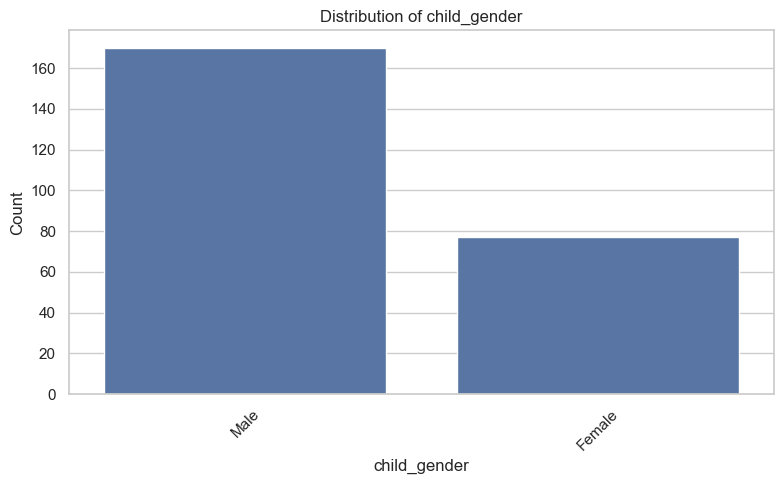

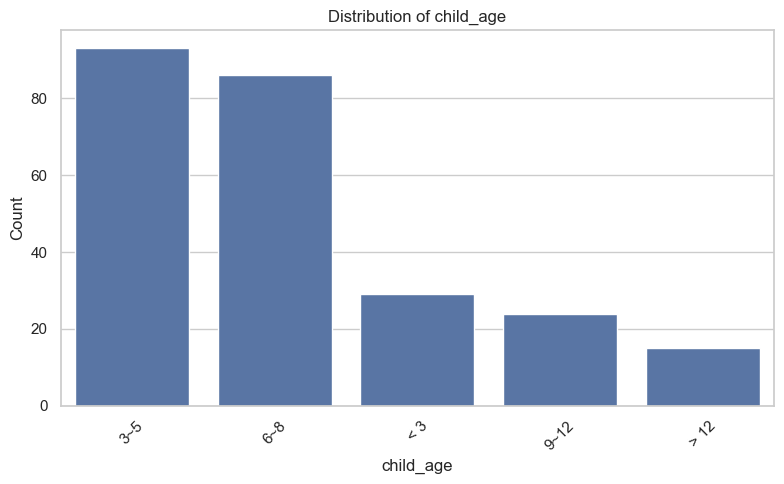

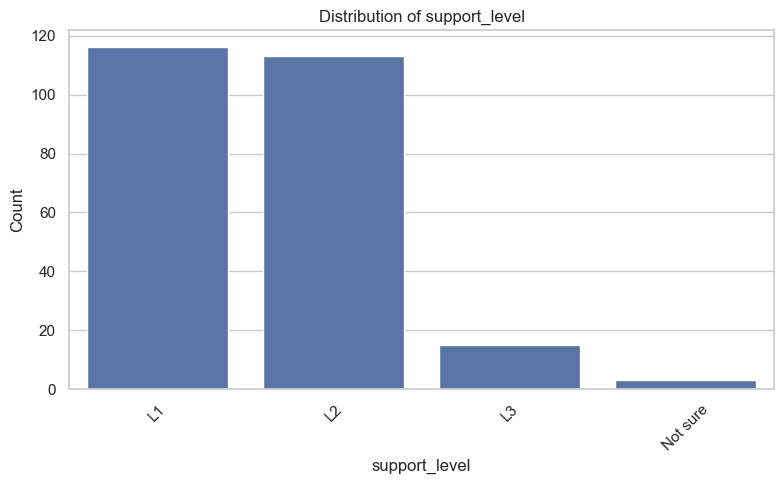

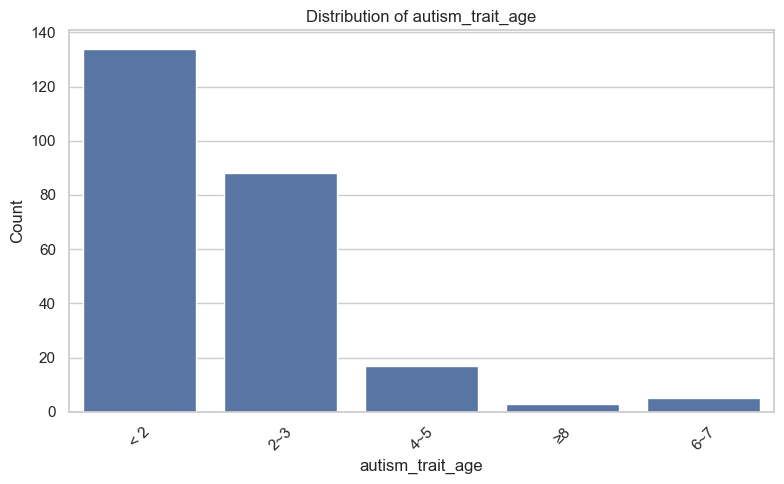

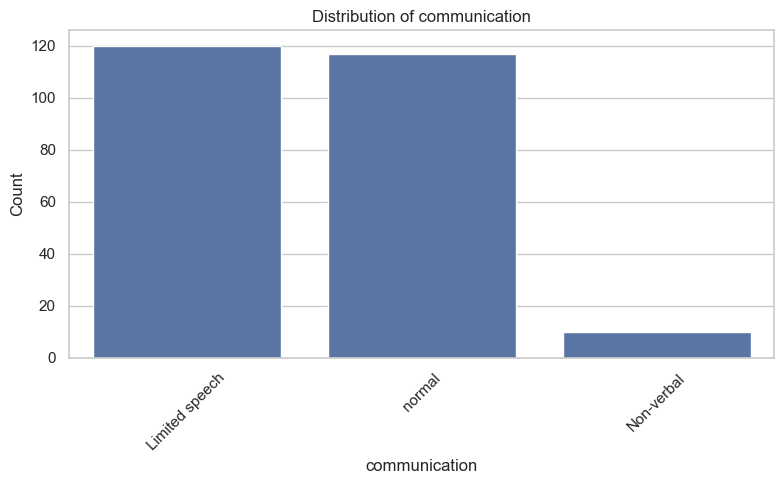

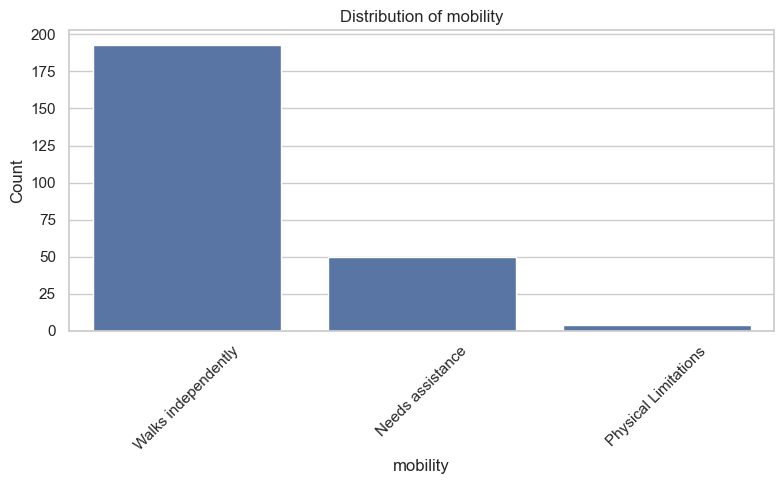

In [10]:
# List of child-related features
child_features = ['child_gender', 'child_age', 'support_level', 
                  'autism_trait_age', 'communication', 'mobility']

sns.set(style="whitegrid")

for feature in child_features:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df_clean, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [11]:
# child_gender
df_clean['child_gender'] = df_clean['child_gender'].map({'Male': 1, 'Female': 0})

# child_age
age_order = {'< 3': 0, '3~5': 1, '6~8': 2, '9~12': 3, '> 12': 4}
df_clean['child_age'] = df_clean['child_age'].map(age_order)

# support_level
support_order = {'Not sure': 0, 'L1': 1, 'L2': 2, 'L3': 3}
df_clean['support_level'] = df_clean['support_level'].map(support_order)

# autism_trait_age
trait_order = {'< 2': 0, '2~3': 1, '4~5': 2, '6~7': 3, '≥8': 4}
df_clean['autism_trait_age'] = df_clean['autism_trait_age'].map(trait_order)

# communication
comm_order = {'Non-verbal': 0, 'Limited speech': 1, 'normal': 2}
df_clean['communication'] = df_clean['communication'].map(comm_order)

# mobility
mob_order = {'Physical Limitations': 0, 'Needs assistance': 1, 'Walks independently': 2}
df_clean['mobility'] = df_clean['mobility'].map(mob_order)

# snoezelen_freq
freq_order = {'Never': 0, '1-2 / Month': 1, '1-3 / Month': 2, '3-6 / Month': 3, '≥7 / Month': 4}
df_clean['snoezelen_freq'] = df_clean['snoezelen_freq'].map(freq_order)

# snoezelen_effective, snoezelen_cost, snoezelen_access, stroller_calming
yn_order = {'No': 0, 'Not sure': 1, 'Yes': 2}
for col in ['snoezelen_effective', 'snoezelen_cost', 'snoezelen_access', 'stroller_calming']:
    df_clean[col] = df_clean[col].map(yn_order)

# stroller_suitable
stroller_order = {'No': 0, 'Yes': 1}
df_clean['stroller_suitable'] = df_clean['stroller_suitable'].map(stroller_order)

# outdoor_duration
outdoor_order = {'<30min': 0, '30-60min': 1, '1-2hr': 2, '>2hr': 3}
df_clean['outdoor_duration'] = df_clean['outdoor_duration'].map(outdoor_order)

# calm_duration
calm_order = {'<10min': 0, '10-30min': 1, '30-60min': 2, '1-2hr': 3, '>2hr': 4}
df_clean['calm_duration'] = df_clean['calm_duration'].replace({'1-2hours':'1-2hr'}).map(calm_order)

# stroller_freq
stroller_freq_map = {
    "Never": 0,
    "Occasionally": 1,
    "Often": 2,
    "Always": 3
}
df_clean["stroller_freq"] = df_clean["stroller_freq"].map(stroller_freq_map)

# rank_1, rank_2, rank_3 (ordinal encoding)
rank_map = {
    "Sensory Intervention": 0,
    "App Control": 1,
    "Smart Sensors": 2
}
df_clean["rank_1"] = df_clean["rank_1"].map(rank_map)
df_clean["rank_2"] = df_clean["rank_2"].map(rank_map)
df_clean["rank_3"] = df_clean["rank_3"].map(rank_map)

# price_range (ordinal encoding)
price_range_map = {
    "<300": 0,
    "300-699": 1,
    "700-1,499": 2,
    "1,500-2,999": 3,
    "3,000-5,999": 4
}
df_clean["price_range"] = df_clean["price_range"].map(price_range_map)

# cg_gender
cg_gender_map = {
    "Male": 0,
    "Female": 1
}
df_clean["cg_gender"] = df_clean["cg_gender"].map(cg_gender_map)

# cg_age (ordinal)
cg_age_map = {
    "< 25": 0,
    "25 - 34": 1,
    "35 - 44": 2,
    "45 - 54": 3,
    "55 +": 4
}
df_clean["cg_age"] = df_clean["cg_age"].map(cg_age_map)

# cg_education (ordinal)
cg_education_map = {
    "Secondary School or below": 0,
    "Pre-University": 1,
    "Diploma": 2,
    "Diploma / Technical certificate": 3,
    "Bachelor": 4,
    "Master or above": 5,
    "Prefer not to say": 6
}
df_clean["cg_education"] = df_clean["cg_education"].map(cg_education_map)

# income (ordinal)
income_map = {
    "≤ 5,000": 0,
    "5,001-10,000": 1,
    "10,001-15,000": 2,
    "15,001-25,000": 3,
    "≥25,000": 4,
    "Prefer not to say": 5
}
df_clean["income"] = df_clean["income"].map(income_map)

# area
area_map = {
    "Urban": 0,
    "Suburban": 1,
    "Rural": 2
}
df_clean["area"] = df_clean["area"].map(area_map)

# relation
relation_map = {
    "Parent": 0,
    "Grandparent": 1,
    "Relative": 2,
    "Teacher": 3,
    "Other": 4
}
df_clean["relation"] = df_clean["relation"].map(relation_map)



In [12]:
for col in df_clean.columns:
    unique_vals = df_clean[col].unique()
    print(f"\n--- {col} ---")
    print(f"Unique count: {len(unique_vals)}")
    print(unique_vals[:10])


--- child_gender ---
Unique count: 2
[1 0]

--- child_age ---
Unique count: 5
[1 2 0 3 4]

--- support_level ---
Unique count: 4
[1 2 3 0]

--- autism_trait_age ---
Unique count: 5
[0 1 2 4 3]

--- communication ---
Unique count: 3
[1 2 0]

--- mobility ---
Unique count: 3
[2 1 0]

--- snoezelen_freq ---
Unique count: 5
[1 0 3 2 4]

--- snoezelen_effective ---
Unique count: 3
[2 1 0]

--- snoezelen_cost ---
Unique count: 3
[2 1 0]

--- snoezelen_access ---
Unique count: 3
[0 1 2]

--- outdoor_duration ---
Unique count: 4
[1 2 3 0]

--- calm_duration ---
Unique count: 5
[1 2 3 4 0]

--- stroller_freq ---
Unique count: 4
[1 2 0 3]

--- stroller_calming ---
Unique count: 3
[2 1 0]

--- stroller_suitable ---
Unique count: 2
[0 1]

--- sensory_light ---
Unique count: 5
[3 5 4 1 2]

--- sensory_noise ---
Unique count: 5
[4 5 3 2 1]

--- sensory_crowds ---
Unique count: 5
[4 5 3 2 1]

--- sensory_meltdown ---
Unique count: 5
[4 3 2 1 5]

--- sensory_outdoor ---
Unique count: 5
[4 1 3 5 2]

-

                     stroller_suitable
stroller_suitable             1.000000
sensory_outdoor               0.184764
confidence_handling           0.155117
snoezelen_freq                0.152832
outdoor_duration              0.150990
...                                ...
sensor_light                 -0.117967
stress_effort                -0.119708
stress_limit                 -0.139944
autism_trait_age             -0.202012
stress_stressed              -0.236172

[82 rows x 1 columns]


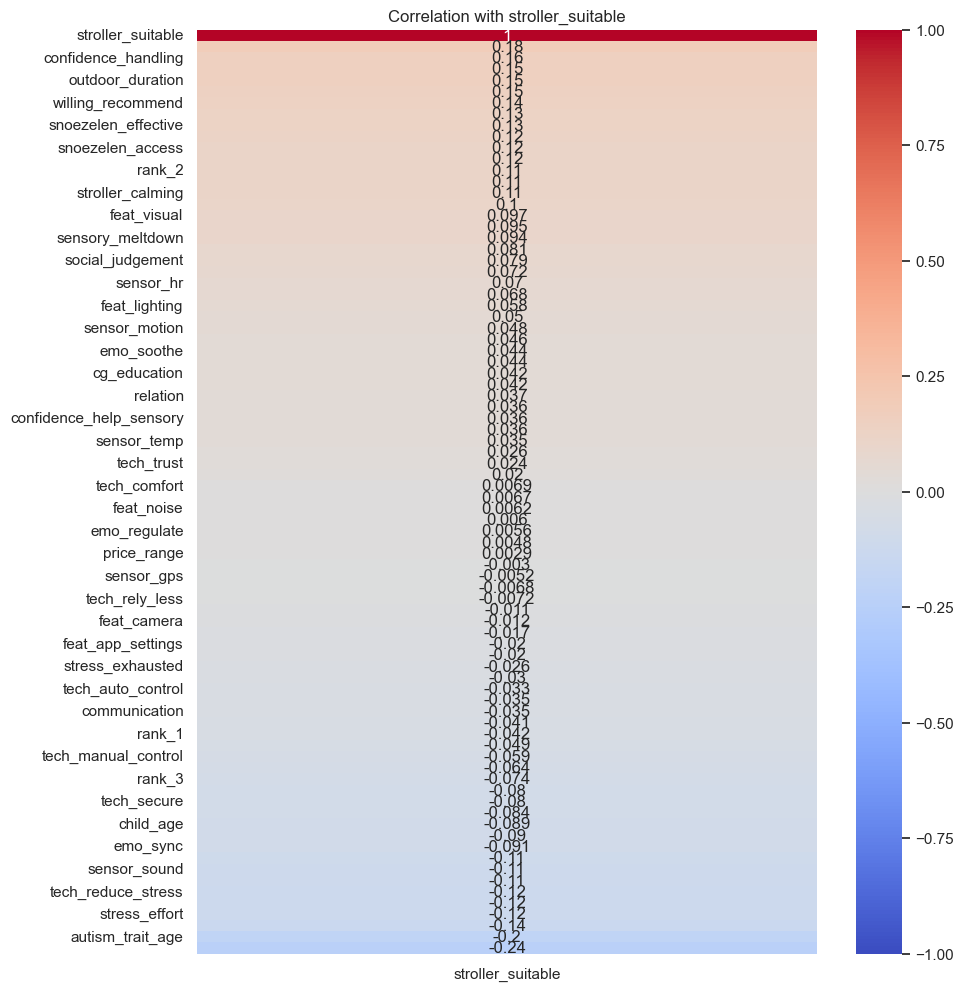

In [13]:
df_corr = df_clean.drop(columns=['open_features'], errors='ignore')
# Compute correlation matrix
corr_matrix = df_corr.corr()

# Focus on correlation with target
target_corr = corr_matrix[['stroller_suitable']].sort_values(by='stroller_suitable', ascending=False)

# Display
print(target_corr)

# Optional: heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation with stroller_suitable')
plt.show()

stroller_suitable
0     80
1    167
Name: count, dtype: int64


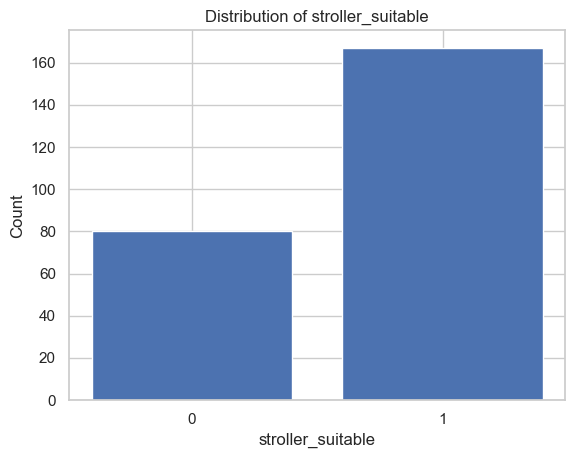

In [14]:
# Check distribution of target variable
counts = df_clean['stroller_suitable'].value_counts().sort_index()

print(counts)

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel('stroller_suitable')
plt.ylabel('Count')
plt.title('Distribution of stroller_suitable')
plt.show()


In [15]:
# Target
y = df_clean['stroller_suitable']

# Drop target and open-ended features
X = df_clean.drop(columns=['stroller_suitable', 'open_features'], errors='ignore')


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Original distribution (proportion):
stroller_suitable
0    0.323887
1    0.676113
Name: proportion, dtype: float64

Training set distribution (proportion):
stroller_suitable
0    0.324873
1    0.675127
Name: proportion, dtype: float64

Test set distribution (proportion):
stroller_suitable
0    0.32
1    0.68
Name: proportion, dtype: float64


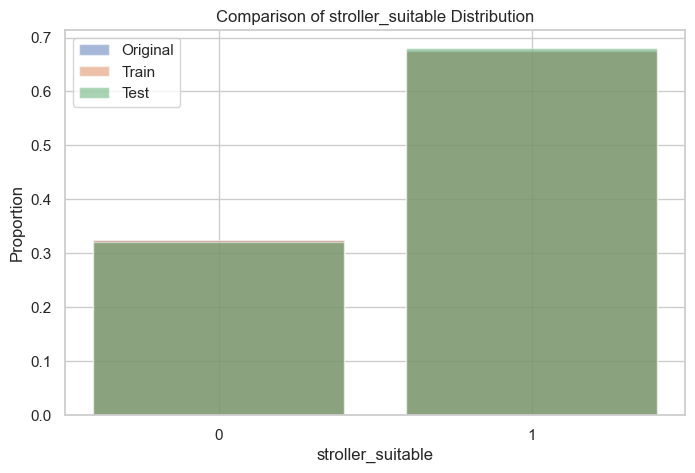

In [17]:
# Original distribution
original_counts = y.value_counts(normalize=True).sort_index()
print("Original distribution (proportion):")
print(original_counts)

# Training set distribution
train_counts = y_train.value_counts(normalize=True).sort_index()
print("\nTraining set distribution (proportion):")
print(train_counts)

# Test set distribution
test_counts = y_test.value_counts(normalize=True).sort_index()
print("\nTest set distribution (proportion):")
print(test_counts)

# Optional: plot comparison
plt.figure(figsize=(8,5))
plt.bar(original_counts.index.astype(str), original_counts.values, alpha=0.5, label='Original')
plt.bar(train_counts.index.astype(str), train_counts.values, alpha=0.5, label='Train')
plt.bar(test_counts.index.astype(str), test_counts.values, alpha=0.5, label='Test')
plt.xlabel('stroller_suitable')
plt.ylabel('Proportion')
plt.title('Comparison of stroller_suitable Distribution')
plt.legend()
plt.show()


In [18]:
# Import necessary libraries
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new distribution after SMOTE
import pandas as pd
print(pd.Series(y_train_res).value_counts())

# Initialize models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=300, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Fit models on SMOTE-resampled training data
log_reg.fit(X_train_res, y_train_res)
rf.fit(X_train_res, y_train_res)
gb.fit(X_train_res, y_train_res)

# Predict on original test set
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

# Evaluate models
models = {"Logistic Regression": y_pred_lr, 
          "Random Forest": y_pred_rf, 
          "Gradient Boosting": y_pred_gb}

for name, y_pred in models.items():
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")


stroller_suitable
0    133
1    133
Name: count, dtype: int64
--- Logistic Regression ---
Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.62      0.65        16
           1       0.83      0.85      0.84        34

    accuracy                           0.78        50
   macro avg       0.75      0.74      0.74        50
weighted avg       0.78      0.78      0.78        50

Confusion Matrix:
[[10  6]
 [ 5 29]]


--- Random Forest ---
Accuracy: 0.74
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.38      0.48        16
           1       0.76      0.91      0.83        34

    accuracy                           0.74        50
   macro avg       0.71      0.64      0.65        50
weighted avg       0.73      0.74      0.72        50

Confusion Matrix:
[[ 6 10]
 [ 3 31]]


--- Gradient Boosting ---
Accuracy: 0.78
Classification Report:
              pr

In [19]:
# -----------------------------
# 1. Scale features for Logistic Regression
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 2. Define models with basic hyperparameter grids
# -----------------------------
models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=5000, class_weight='balanced'),
        "params": {
            "C":  [0.05, 0.1, 0.5, 1, 5],
            "solver": ['lbfgs', 'liblinear'],
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 300],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5]
        }
    }
}

# -----------------------------
# 3. Grid search with 5-fold stratified CV
# -----------------------------
best_models = {}
for name, mp in models.items():
    print(f"Training {name}...")
    clf = GridSearchCV(mp["model"], mp["params"], cv=StratifiedKFold(n_splits=5), scoring='f1_weighted', n_jobs=-1)
    if name == "LogisticRegression":
        clf.fit(X_train_scaled, y_train)
    else:
        clf.fit(X_train, y_train)
    best_models[name] = clf.best_estimator_
    print(f"Best params: {clf.best_params_}\n")

# -----------------------------
# 4. Evaluate models on test set
# -----------------------------
for name, model in best_models.items():
    print(f"\n{name} Classification Report:")
    if name == "LogisticRegression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Training LogisticRegression...
Best params: {'C': 0.05, 'solver': 'lbfgs'}

Training RandomForest...
Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

Training GradientBoosting...
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


LogisticRegression Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.62      0.51        16
           1       0.78      0.62      0.69        34

    accuracy                           0.62        50
   macro avg       0.61      0.62      0.60        50
weighted avg       0.67      0.62      0.63        50

Confusion Matrix:
[[10  6]
 [13 21]]

RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.31      0.42        16
           1       0.74      0.91      0.82        34

    accuracy                           0.72        50
   macro avg       0.68      0.61      0.62        50
weig

In [20]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Suitable', 'Suitable'],
        yticklabels=['Not Suitable', 'Suitable']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()


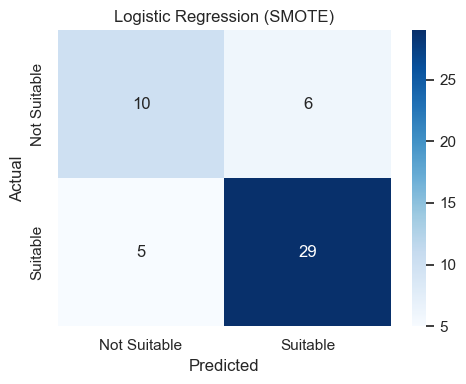

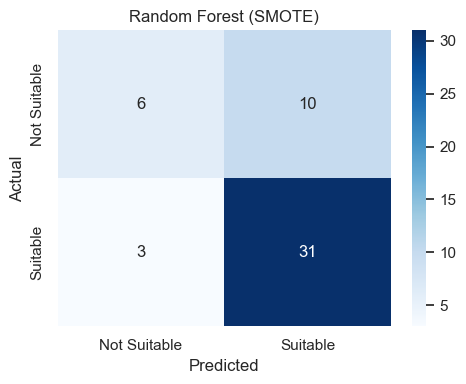

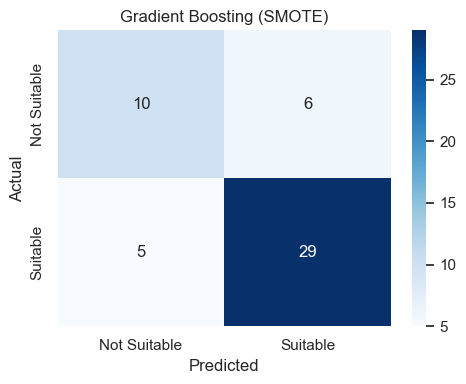

In [21]:
# Logistic Regression (SMOTE)
plot_confusion_matrix(
    y_test,
    y_pred_lr,
    'Logistic Regression (SMOTE)'
)

# Random Forest (SMOTE)
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    'Random Forest (SMOTE)'
)

# Gradient Boosting (SMOTE)
plot_confusion_matrix(
    y_test,
    y_pred_gb,
    'Gradient Boosting (SMOTE)'
)


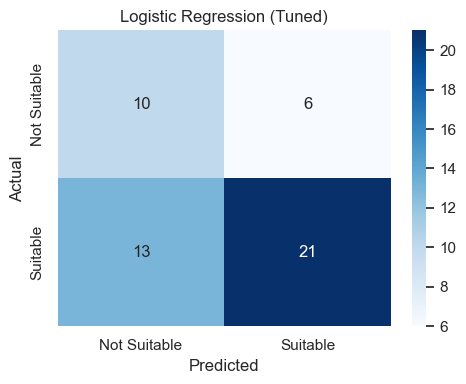

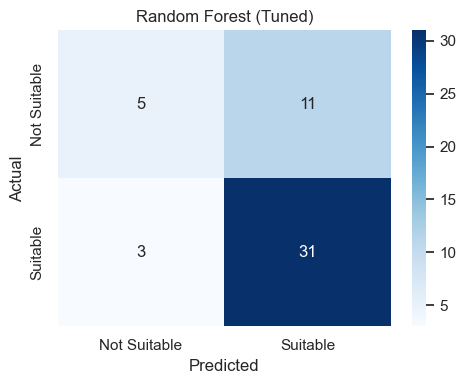

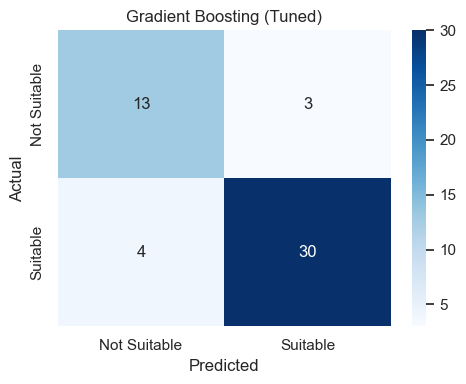

In [22]:
# Logistic Regression (Tuned)
y_pred_lr_tuned = best_models['LogisticRegression'].predict(X_test_scaled)
plot_confusion_matrix(
    y_test,
    y_pred_lr_tuned,
    'Logistic Regression (Tuned)'
)

# Random Forest (Tuned)
y_pred_rf_tuned = best_models['RandomForest'].predict(X_test)
plot_confusion_matrix(
    y_test,
    y_pred_rf_tuned,
    'Random Forest (Tuned)'
)

# Gradient Boosting (Tuned)
y_pred_gb_tuned = best_models['GradientBoosting'].predict(X_test)
plot_confusion_matrix(
    y_test,
    y_pred_gb_tuned,
    'Gradient Boosting (Tuned)'
)


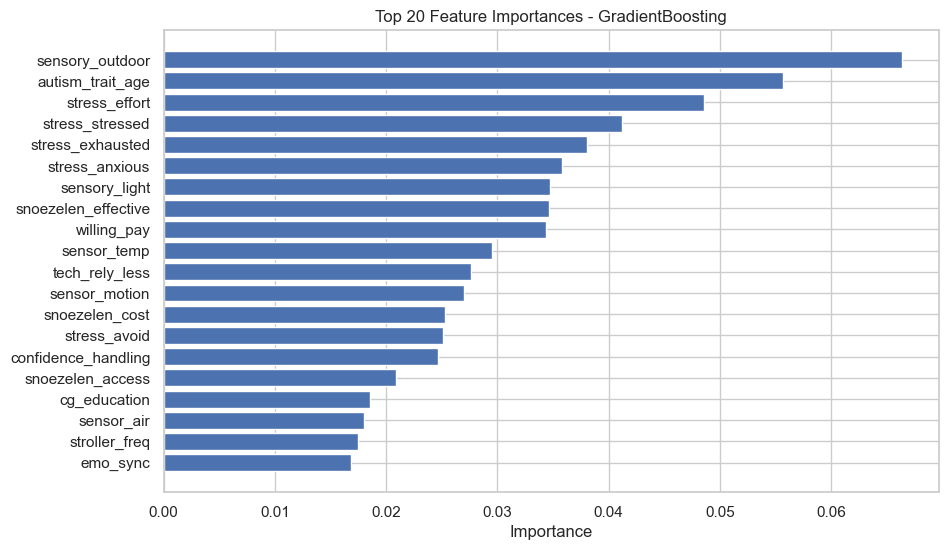

In [23]:
# -----------------------------
# Feature importance for Gradient Boosting
# -----------------------------
def plot_feature_importance(model, model_name, X_columns):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        print(f"{model_name} has no feature importance")
        return
    
    fi_df = pd.DataFrame({"feature": X_columns, "importance": importances})
    fi_df = fi_df.sort_values(by="importance", ascending=False).head(20)
    
    plt.figure(figsize=(10,6))
    plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
    plt.title(f"Top 20 Feature Importances - {model_name}")
    plt.xlabel("Importance")
    plt.show()

# Plot only for Gradient Boosting
plot_feature_importance(best_models["GradientBoosting"], "GradientBoosting", X_train.columns)

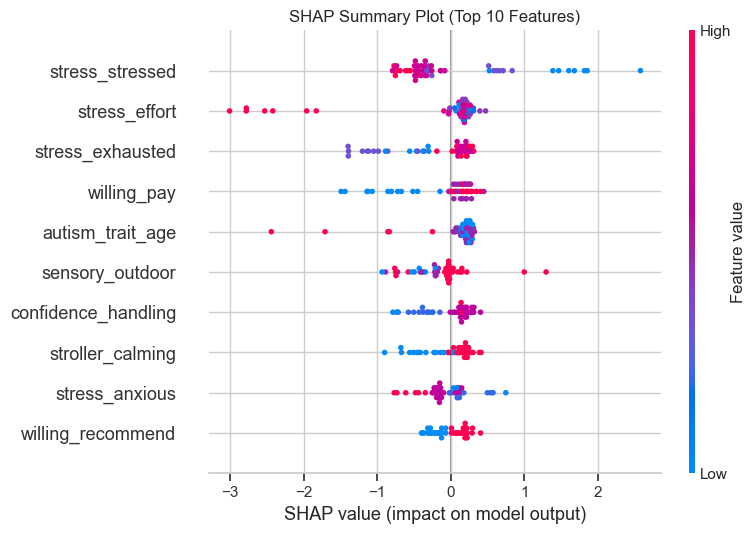

Top 10 Features by Mean Absolute SHAP Value:
                Feature  Mean |SHAP Value|
22      stress_stressed           0.659756
21        stress_effort           0.505887
23     stress_exhausted           0.403878
73          willing_pay           0.344527
3      autism_trait_age           0.307716
18      sensory_outdoor           0.278402
31  confidence_handling           0.262175
13     stroller_calming           0.238756
24       stress_anxious           0.223869
74    willing_recommend           0.192266


In [24]:
# SHAP explainer for tuned Gradient Boosting model
explainer = shap.TreeExplainer(best_models['GradientBoosting'])
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title("SHAP Summary Plot (Top 10 Features)")
plt.tight_layout()
plt.show()

# Mean absolute SHAP values
shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP Value|": shap_importance
}).sort_values(by="Mean |SHAP Value|", ascending=False)

# Print top 10 features
print("Top 10 Features by Mean Absolute SHAP Value:")
print(shap_df.head(10))
